In [11]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanupy

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [12]:
df_in = df[df['job_country'] == 'India'].copy()

df_in['job_posted_month'] = df_in['job_posted_date'].dt.month_name()


In [13]:

df_in_pivot = df_in.pivot_table(index= 'job_posted_month', columns='job_title_short',  aggfunc= 'size')
df_in_pivot.reset_index(inplace=True) # a new index is added and job_posted month becomes a column to be accessed
df_in_pivot['job_posted_month_no'] = pd.to_datetime(df_in_pivot['job_posted_month'], format= '%B').dt.month # new month number col created using name col
df_in_pivot.sort_values(by='job_posted_month_no', inplace=True) # the month number col is used to sort the pivot table
df_in_pivot.set_index('job_posted_month', inplace=True) # the old month name col is set as index
df_in_pivot.drop(columns='job_posted_month_no', inplace= True) # the job_posted_month_no (which now became a column) is dropped

df_in_pivot 

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,175,31,628,2132,1444,70,127,448,269,192
February,143,35,433,1631,932,42,94,313,165,157
March,116,37,422,1591,1005,34,96,351,194,180
April,170,32,418,1566,946,54,86,375,194,169
May,103,14,278,1384,837,31,59,329,134,98
June,146,26,367,1632,1129,41,66,427,238,125
July,142,25,457,1528,1123,54,75,359,204,155
August,189,25,618,1407,1157,47,126,343,235,148
September,155,34,630,1508,984,67,85,324,195,132


In [14]:
import random

# Set seed for reproducibility
random.seed(42)

# Define job titles
job_titles = ['Front-End Developer', 'Back-End Developer', 'Full-Stack Developer', 'UI/UX Designer']

# Define months
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# Define ranges for random data
ranges = {
    'Front-End Developer': (11000, 15000),
    'Back-End Developer': (8000, 10000),
    'Full-Stack Developer': (5000, 7500),
    'UI/UX Designer': (4000, 5000)
}

# Generate random data
data = {}
for job_title in job_titles:
    data[job_title] = [random.randint(ranges[job_title][0], ranges[job_title][1]) for _ in months]

# Create DataFrame
df_in_software_pivot = pd.DataFrame(data, index=months)
df_in_software_pivot.index.name = "job_posted_month"

df_in_software_pivot #Fake data for merging

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [19]:
df_in_merged = df_in_pivot.merge(df_in_software_pivot, on= 'job_posted_month')

In [21]:
top_5 = (df_in_merged
         .sum()
         .sort_values(ascending = False)
         .head()
         .index)

top_5 = top_5.tolist()

top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'UI/UX Designer',
 'Data Engineer']

<Axes: xlabel='job_posted_month'>

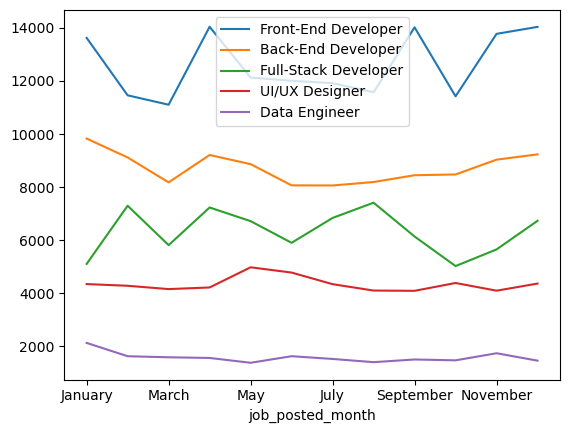

In [24]:
df_in_merged.loc[:, top_5].plot(kind = 'line')